In [1]:
import os
import pickle
import logging
import numpy as np
from scipy.stats import wasserstein_distance
import matplotlib.pyplot as plt
import h5py
import jax
import jax.numpy as jnp
from flax import nnx
from heavyhex_qft.triangular_z2 import TriangularZ2Lattice
from heavyhex_qft.plaquette_dual import PlaquetteDual
from heavyhex_qft.subspace import subspace_projection
from heavyhex_qft.utils import as_bitarray
from qiimk.circuits import make_plaquette_circuits
from qiimk.recovery_learning import preprocess
from qiimk.crbm import ConditionalRBM

os.environ['CUDA_VISIBLE_DEVICES'] = '0'
jax.config.update('jax_enable_x64', True)

logging.basicConfig(level=logging.WARNING)
logging.getLogger('qiimk').setLevel(logging.INFO)

In [2]:
raw_data = {}
with h5py.File('/data/iiyama/2dz2/exp_data/pittsburgh_19links_k05_dt06_6steps_cz_d2qlmiholshc73bmcadg.h5', 'r') as source:
    for group_name, group in source.items():
        if group_name == 'parameters':
            lattice_conf = group['lattice'][()].decode()
            plaquette_energy = group['plaquette_energy'][()]
            delta_t = group['delta_t'][()]
            continue

        raw_data[str(group_name)] = {
            'link_states': group['link_states'][()],
            'counts': group['counts'][()],
        }

In [3]:
#lattice = TriangularZ2Lattice(configuration)
lattice = TriangularZ2Lattice(lattice_conf)
dual_lattice = PlaquetteDual(lattice)

In [ ]:
id_plaq_counts = {key.replace('id_', ''): preprocess((data['link_states'], data['counts']), dual_lattice, as_counts=True)
                  for key, data in raw_data.items() if key.startswith('id_')}
fwd_plaq_counts = {key.replace('fwd_', ''): preprocess((data['link_states'], data['counts']), dual_lattice, as_counts=True)
                   for key, data in raw_data.items() if key.startswith('fwd_')}

In [6]:
basis = set()
for counts in fwd_plaq_counts.values():
    basis |= set(plaq_state for _, plaq_state in counts.keys())

In [7]:
len(basis)

1022

In [8]:
fwd_plaq_data = {key.replace('fwd_', ''): preprocess((data['link_states'], data['counts']), dual_lattice, shuffle=True)
                 for key, data in raw_data.items() if key.startswith('fwd_')}

In [27]:
basis_sub = np.unique(np.concatenate([data[:10, lattice.num_vertices:] for data in fwd_plaq_data.values()], axis=0), axis=0)

In [28]:
idx = np.sum(basis_sub * (1 << np.arange(lattice.num_plaquettes)[None, :]), axis=1)
np.sum(gs_probs[idx])

np.float64(0.9656372511944097)

In [29]:
idx

array([  0, 512, 768,  64, 576,  32, 480,  16, 272, 656,  80,  72, 584,
       200,  24, 516,  68, 660,  12, 258, 162,   1,  65, 163])

In [25]:
np.argsort(gs_probs)[::-1][:10]

array([  0,  64,   8,   1,   4, 512, 128,  32, 256,   2])

In [26]:
gs_probs[0]

np.float64(0.9324363886799709)

In [15]:
hamiltonian = dual_lattice.make_hamiltonian(plaquette_energy)
hmat = hamiltonian.to_matrix()
evals, evecs = np.linalg.eigh(hmat)

In [17]:
gs_probs = np.square(np.abs(evecs[:, 0]))
cumprob = np.cumsum(np.sort(gs_probs)[::-1])

In [20]:
cumprob[30]

np.float64(0.9987906885562758)

In [ ]:
zero_state = (0,) * lattice.num_plaquettes
for key, counts in plaq_counts.items():
    if not key.startswith('id_'):
        continue

    print(key, sum(count for (syndrome, plaq_state), count in counts.items() if plaq_state == zero_state))

id_step1 77071
id_step2 55798
id_step3 42688
id_step4 35286
id_step5 24831
id_step6 16235


In [22]:
from collections import defaultdict
for key, counts in plaq_counts.items():
    if not key.startswith('id_'):
        continue
    ideal_values = [0]
    counts_collapsed = defaultdict(int)
    for (_, plaq_state), count in counts.items():
        counts_collapsed[plaq_state] += count
    obs_values = []
    obs_weights = []
    for plaq_state, count in counts_collapsed.items():
        idx = np.sum(np.array(plaq_state) * (1 << np.arange(lattice.num_plaquettes)))
        obs_values.append(idx)
        obs_weights.append(count)
    print(key, wasserstein_distance(obs_values, ideal_values, obs_weights))

id_step1 38.26896
id_step2 86.95407000000002
id_step3 122.4417
id_step4 144.17006999999998
id_step5 187.65082999999998
id_step6 227.89981000000003


In [6]:
from qiskit_aer import AerSimulator

single_trotter, forward, backward, measure = make_plaquette_circuits(dual_lattice, plaquette_energy, delta_t)
simulator = AerSimulator()

circuit = single_trotter.copy_empty_like()
for istep in range(len(raw_data) // 2):
    circuit.compose(single_trotter, inplace=True)
    circuit.save_statevector(f'step{istep + 1}')
sim_res = simulator.run(circuit).result()

In [23]:
sim_data = sim_res.data()
for key, counts in plaq_counts.items():
    if not key.startswith('fwd_'):
        continue
    ideal_values = np.arange(2 ** lattice.num_plaquettes)
    ideal_weights = np.square(np.abs(sim_data[f'step{istep + 1}'].data))
    counts_collapsed = defaultdict(int)
    for (_, plaq_state), count in counts.items():
        counts_collapsed[plaq_state] += count
    obs_values = []
    obs_weights = []
    for plaq_state, count in counts_collapsed.items():
        idx = np.sum(np.array(plaq_state) * (1 << np.arange(lattice.num_plaquettes)))
        obs_values.append(idx)
        obs_weights.append(count)
    print(key, wasserstein_distance(obs_values, ideal_values, obs_weights, ideal_weights))

fwd_step1 31.286886111314875
fwd_step2 48.831692699836225
fwd_step3 69.06073587142164
fwd_step4 88.87105040716489
fwd_step5 99.72613034925655
fwd_step6 126.57739196184035


In [ ]:
sim_data = sim_res.data()
for istep in range(len(raw_data) // 2):
    sim_prob = np.square(np.abs(sim_data[f'step{istep + 1}'].data))
    obs_prob = np.zeros_like(sim_prob)
    counts = plaq_counts[f'fwd_step{istep + 1}']
    total = sum(counts.values())
    for (syndrome, plaq_state), count in counts.items():
        idx = np.sum(np.array(plaq_state) * (1 << np.arange(lattice.num_plaquettes)))
        obs_prob[idx] += count / total

    log_p = np.zeros_like(sim_prob)
    log_q = np.zeros_like(sim_prob)
    np.log(obs_prob, out=log_p, where=np.logical_not(np.isclose(obs_prob, 0.)))
    np.log(sim_prob, out=log_q, where=np.logical_not(np.isclose(sim_prob, 0.)))
    kl_div = np.sum(obs_prob * (log_p - log_q))
    print(istep, kl_div)

0 0.2197179716784593
1 0.6839255077609575
2 0.339370784748004
3 0.7329741326829762
4 0.4103668664783934
5 0.628799995283835


In [24]:
obs_prob

array([0.55371, 0.03447, 0.01503, ..., 0.     , 0.     , 0.     ],
      shape=(1024,))

In [10]:
syndromes = np.sum(data[:, :lattice.num_vertices] * (1 << np.arange(lattice.num_vertices)[None, ::-1]), axis=1)
plaquette_states = np.sum(data[:, lattice.num_vertices:] * (1 << np.arange(lattice.num_plaquettes)[None, ::-1]), axis=1)

In [16]:
distribution = np.zeros((2 ** lattice.num_vertices, 2 ** lattice.num_plaquettes), dtype=np.uint16)
for syndrome, state in zip(syndromes, plaquette_states):
    distribution[syndrome, state] += 1

<Figure size 2000x2000 with 0 Axes>

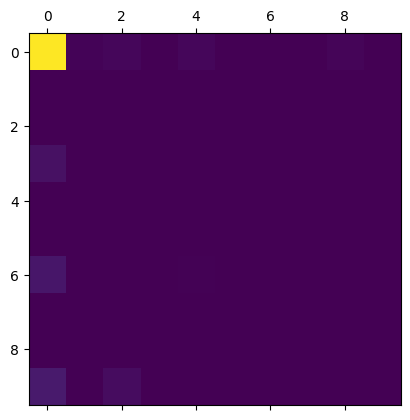

In [22]:
plt.figure(figsize=(20, 20))
plt.matshow(distribution[:10, :10])


In [21]:
np.nonzero(distribution)[0].shape

(5099,)

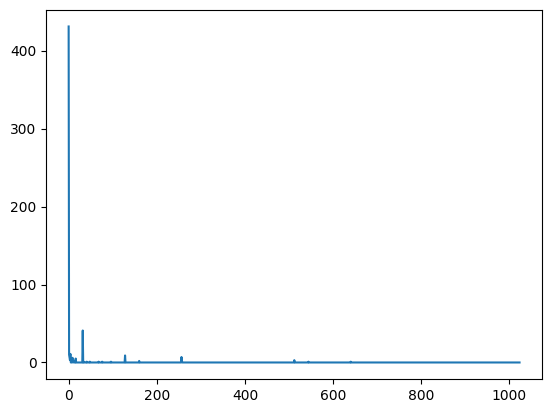

In [26]:
plt.plot(distribution[3])

In [5]:
np.random.shuffle(data)

In [6]:
train_dataset = data[:40000]
test_dataset = data[40000:]

In [7]:
from qiimk.crbm import ConditionalRBM, train_crbm

In [8]:
from flax import nnx
rngs = nnx.Rngs(params=0, sample=1)
model = ConditionalRBM(10, 10, 64, rngs=rngs)

metrics = train_crbm(model, train_dataset, test_dataset, batch_size=1000, num_epochs=10)

INFO:qiimk.crbm:Starting epoch 0/10
INFO:qiimk.crbm:Starting epoch 1/10
INFO:qiimk.crbm:Starting epoch 2/10
INFO:qiimk.crbm:Starting epoch 3/10
INFO:qiimk.crbm:Starting epoch 4/10
INFO:qiimk.crbm:Starting epoch 5/10
INFO:qiimk.crbm:Starting epoch 6/10
INFO:qiimk.crbm:Starting epoch 7/10
INFO:qiimk.crbm:Starting epoch 8/10
INFO:qiimk.crbm:Starting epoch 9/10


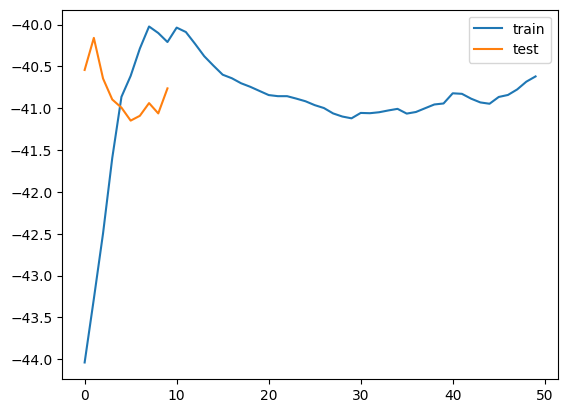

In [9]:
plt.plot(metrics['train_free_energy'], label='train')
plt.plot(metrics['test_free_energy'], label='test')
plt.legend();

In [33]:
train_f = np.mean(model.free_energy(train_dataset[:, :10], train_dataset[:, 10:]))
test_f = np.mean(model.free_energy(test_dataset[:, :10], test_dataset[:, 10:]))

In [34]:
train_f, test_f

(Array(-40.860527, dtype=float32), Array(-40.888382, dtype=float32))

In [35]:
model_tmp = ConditionalRBM(10, 10, 64, rngs=rngs)
print(np.mean(model_tmp.free_energy(train_dataset[:, :10], train_dataset[:, 10:])))
print(np.mean(model_tmp.free_energy(test_dataset[:, :10], test_dataset[:, 10:])))

-44.932613
-44.918518
